##Guilherme da Mata Garzon - 15456601

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import scipy.sparse as sps

In [2]:
def cond_inicial(x):
  return np.exp(-20*((x-2)**2)) + np.exp(-(x-5)**2)

##Tarefa 1 - Progressivas no Tempo e Centrais no Espaço

In [3]:
#Construção das ferramentas do problema

def monta_sistema_1(delta_x,Pe,N_x):
  delta_t = min(delta_x, (delta_x**2)/((2/Pe)+delta_x))/2
  N_t = int(12/delta_t)
  cte_1 = 1 - 2*delta_t/((delta_x**2) * Pe) #u(i)
  cte_2 = delta_t/((delta_x**2)*Pe) + delta_t/(2*delta_x) #u(i+1)
  cte_3 = delta_t/((delta_x**2)*Pe) - delta_t/(2*delta_x) #u(i-1)

  #Definição da matriz. Construímos a diagonal e as condições periódicas em um bloco
  #para montar uma matriz esparsa do scipy
  diagonais = [
      np.full(N_x, cte_1),       # Diagonal principal
      np.full(N_x - 1, cte_2),   # Subdiagonal inferior (-1)
      np.full(N_x - 1, cte_3),   # Superdiagonal (1)
      np.array([cte_2]),         # Canto superior direito (cond. periódica)
      np.array([cte_3])          # Canto inferior esquerdo (cond. periódica)
  ]
  offsets = [0, -1, 1, N_x - 1, -(N_x - 1)]

  # Constrói em formato CSR
  A = sps.diags(diagonais, offsets, format='csr')
  return A, N_t

In [4]:
#Vamos construir 4 situações para diferentes constantes de Péclet

#Faz uma lista com os valores de Pe:
#Pe<<1
#Pe = 1
#Pe>>1(Pe = 100 e Pe = 300)
lista_Pe = [0.1,1,100,300]

#Constantes
delta_x = 0.05
N_x = int(15/delta_x)
x = np.linspace(0,15,N_x)

V = np.array(cond_inicial(x))

#Dicionário para guardar os resultados de maneira eficiente
resultados = {}

for Pe in lista_Pe:

    #Monta o sistema
    A, N_t = monta_sistema_1(delta_x, Pe, N_x)

    #Inicializa as variáveis temporais e a grid
    t = np.linspace(0, 12, N_t)
    X, T = np.meshgrid(x, t)

    #Matriz dos resultados
    U = np.zeros((N_t, N_x))
    U[0, :] = V

    #Loop temporal
    for i in range(1, N_t):
        U[i, :] = A.dot(U[i-1, :])

    #Salva todos os dados importantes em um dicionário
    #Isso facilita a generalização
    resultados[Pe] = {
        'U': U,
        'X': X,
        'T': T,
        't': t
    }

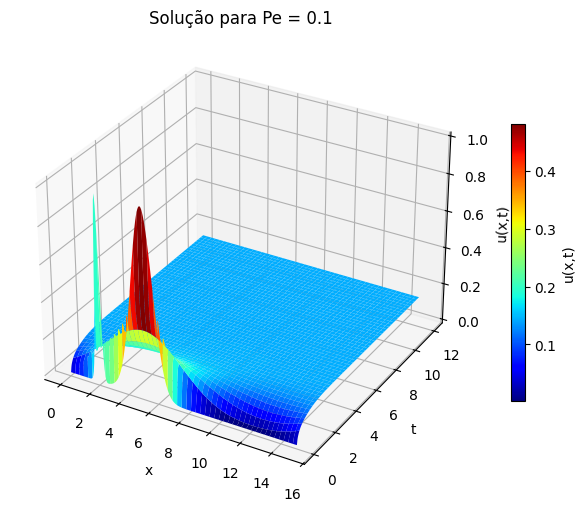

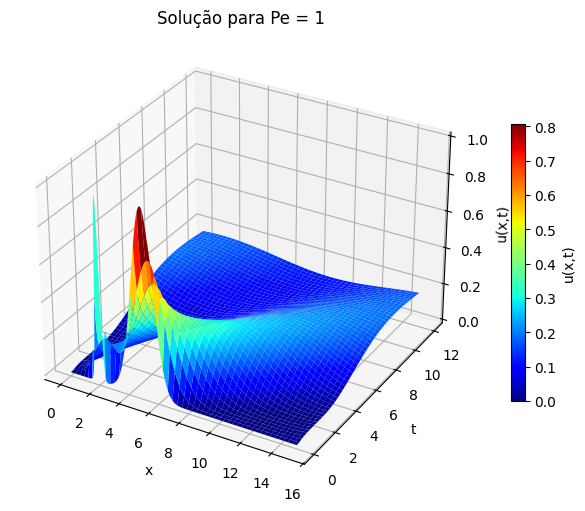

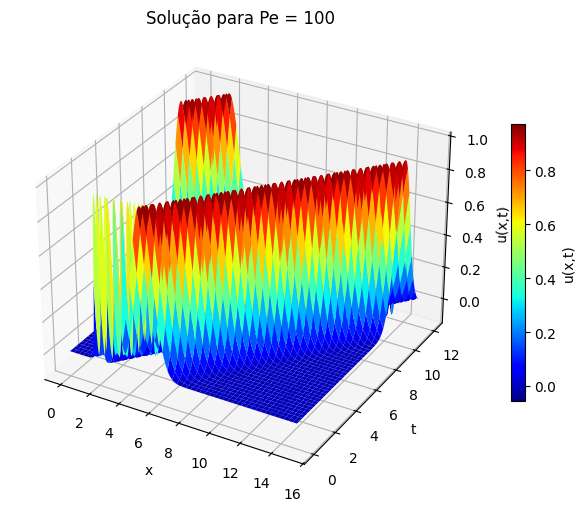

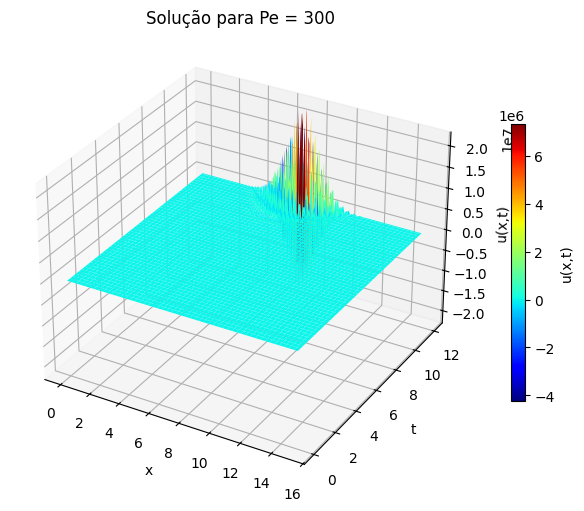

In [5]:
#Criação dos Gráficos

#Caso 1
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

#Plota a superfície
surf = ax.plot_surface(
    resultados[0.1]['X'],
    resultados[0.1]['T'],
    resultados[0.1]['U'],
    cmap='jet',
    edgecolor='none'
)

fig.colorbar(surf, ax=ax, shrink=0.6, label='u(x,t)')

#Ajeita o gráfico e faz o plot final
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title('Solução para Pe = 0.1')
plt.show()


#Caso 2
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

#Plota a superfície
surf = ax.plot_surface(
    resultados[1]['X'],
    resultados[1]['T'],
    resultados[1]['U'],
    cmap='jet',
    edgecolor='none'
)

fig.colorbar(surf, ax=ax, shrink=0.6, label='u(x,t)')

#Ajeita o gráfico e faz o plot final
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title('Solução para Pe = 1')
plt.show()


#Caso 3
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

#Plota a superfície
surf = ax.plot_surface(
    resultados[100]['X'],
    resultados[100]['T'],
    resultados[100]['U'],
    cmap='jet',
    edgecolor='none'
)

fig.colorbar(surf, ax=ax, shrink=0.6, label='u(x,t)')

#Ajeita o gráfico e faz o plot final
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title('Solução para Pe = 100')
plt.show()


#Caso 4
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

#Plota a superfície
surf = ax.plot_surface(
    resultados[300]['X'],
    resultados[300]['T'],
    resultados[300]['U'],
    cmap='jet',
    edgecolor='none'
)

fig.colorbar(surf, ax=ax, shrink=0.6, label='u(x,t)')

#Ajeita o gráfico e faz o plot final
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title('Solução para Pe = 300')
plt.show()


##Tarefa 2 - Upwind para termo advectivo

In [6]:
#Como a diferença do método muda, somente, algumas constantes, usamos a mesma estratégia
#para montar o sistema

def monta_sistema_2(delta_x,Pe,N_x):
  delta_t = min(delta_x, (delta_x**2)/((2/Pe)+delta_x))/2
  N_t = int(12/delta_t)
  cte_1 = 1 - 2*delta_t/((delta_x**2) * Pe) - delta_t/delta_x #u(i)
  cte_2 = delta_t/((delta_x**2)*Pe) #u(i+1)
  cte_3 = delta_t/((delta_x**2)*Pe) + delta_t/(delta_x) #u(i-1)

  #Usamos a mesma técnica da tarefa 1 para a montagem de uma matriz esparsa

  diagonais = [
      np.full(N_x, cte_1),
      np.full(N_x - 1, cte_2),
      np.full(N_x - 1, cte_3),
      np.array([cte_2]),
      np.array([cte_3])
  ]
  offsets = [0, -1, 1, N_x - 1, -(N_x - 1)]

  A = sps.diags(diagonais, offsets, format='csr')

  return A.transpose().tocsr(), N_t

In [7]:
#Vamos testar o problema com 5 valores de Pe

#Faz uma lista com os valores de Pe:
#Pe = 0.01
#Pe = 0.5
#Pe = 1
#Pe = 10
#Pe = 100
#Pe = 300
lista_Pe = [0.1,0.5,1,10,100,300]

#Constantes
delta_x = 0.05
N_x = int(15/delta_x)
x = np.linspace(0,15,N_x)

V = np.array(cond_inicial(x))

#Dicionário para guardar os resultados de maneira eficiente
resultados_2 = {}

for Pe in lista_Pe:

    #Monta o sistema
    A, N_t = monta_sistema_2(delta_x, Pe, N_x)

    #Inicializa as variáveis temporais e a grid
    t = np.linspace(0, 12, N_t)
    X, T = np.meshgrid(x, t)

    #Matriz dos resultados
    U = np.zeros((N_t, N_x))
    U[0, :] = V

    #Loop temporal
    for i in range(1, N_t):
        U[i, :] = A.dot(U[i-1, :])

    #Salva todos os dados importantes em um dicionário
    #Isso facilita a generalização
    resultados_2[Pe] = {
        'U': U,
        'X': X,
        'T': T,
        't': t
    }

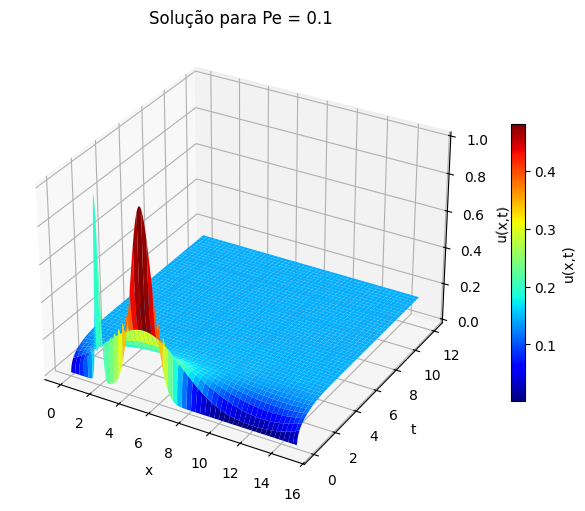

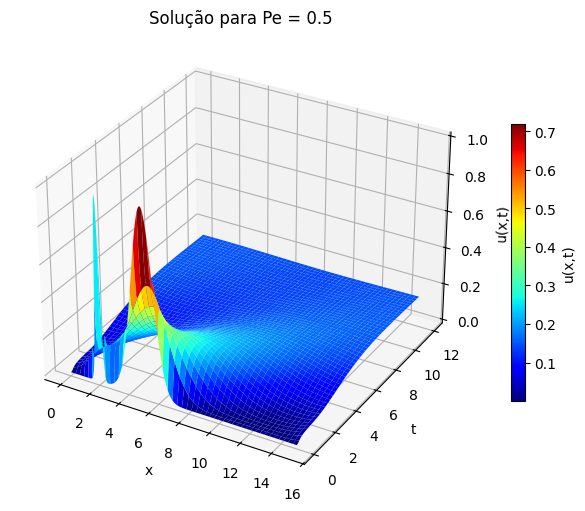

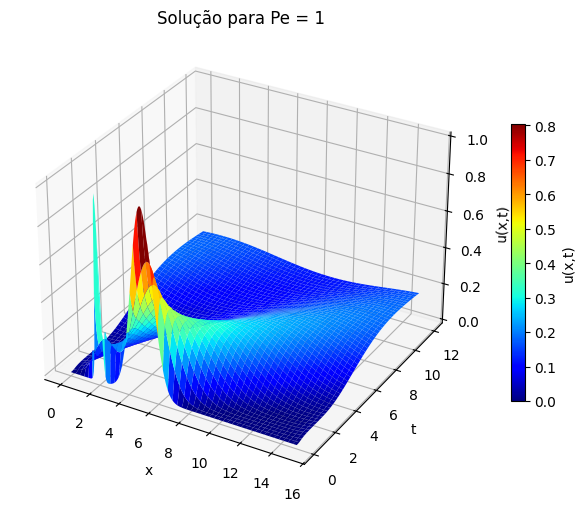

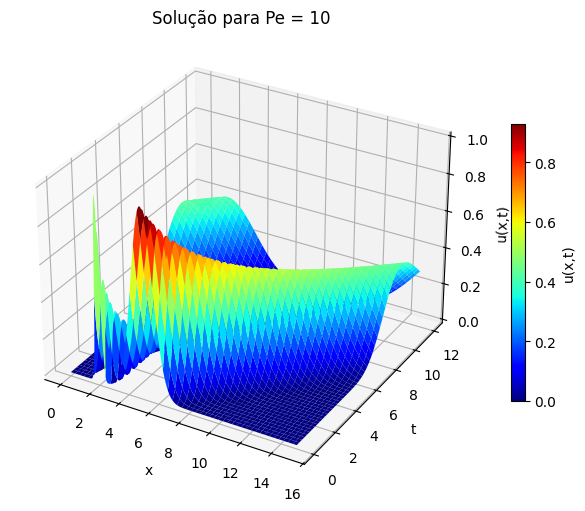

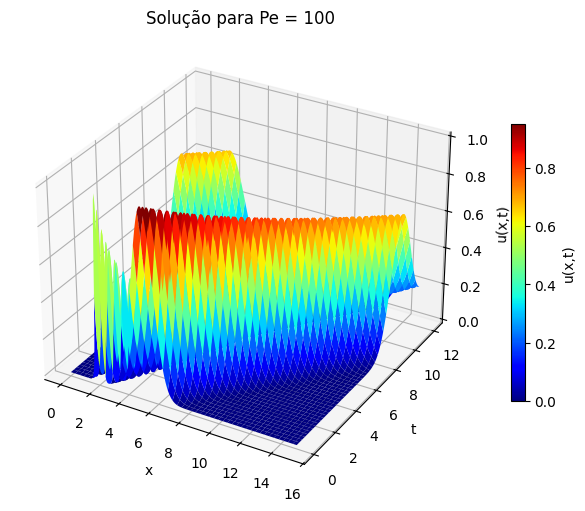

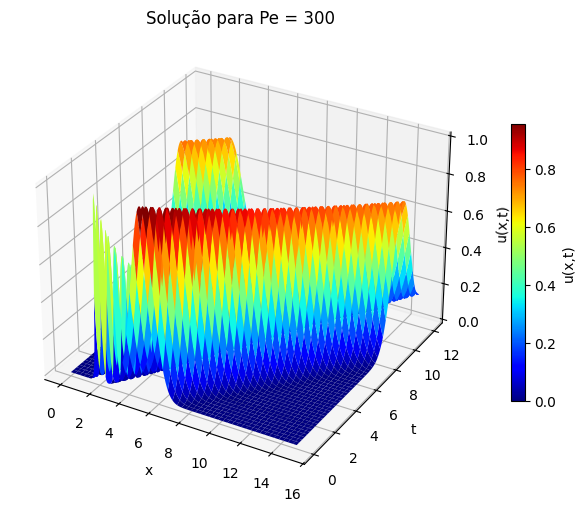

In [8]:
#Criação dos Gráficos Tridimensionais

#Caso 1
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

#Superfície
surf = ax.plot_surface(
    resultados_2[0.1]['X'],
    resultados_2[0.1]['T'],
    resultados_2[0.1]['U'],
    cmap='jet',
    edgecolor='none'
)

fig.colorbar(surf, ax=ax, shrink=0.6, label='u(x,t)')

#Ajeita o gráfico e faz o plot final
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title('Solução para Pe = 0.1')
plt.show()



#Caso 2
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

#Superfície
surf = ax.plot_surface(
    resultados_2[0.5]['X'],
    resultados_2[0.5]['T'],
    resultados_2[0.5]['U'],
    cmap='jet',
    edgecolor='none'
)

fig.colorbar(surf, ax=ax, shrink=0.6, label='u(x,t)')

#Ajeita o gráfico e faz o plot final
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title('Solução para Pe = 0.5')
plt.show()



#Caso 3
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

#Superfície
surf = ax.plot_surface(
    resultados_2[1]['X'],
    resultados_2[1]['T'],
    resultados_2[1]['U'],
    cmap='jet',
    edgecolor='none'
)

fig.colorbar(surf, ax=ax, shrink=0.6, label='u(x,t)')

#Ajeita o gráfico e faz o plot final
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title('Solução para Pe = 1')
plt.show()




#Caso 4
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

#Superfície
surf = ax.plot_surface(
    resultados_2[10]['X'],
    resultados_2[10]['T'],
    resultados_2[10]['U'],
    cmap='jet',
    edgecolor='none'
)

fig.colorbar(surf, ax=ax, shrink=0.6, label='u(x,t)')

#Ajeita o gráfico e faz o plot final
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title('Solução para Pe = 10')
plt.show()



#Caso 5
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

#Superfície
surf = ax.plot_surface(
    resultados_2[100]['X'],
    resultados_2[100]['T'],
    resultados_2[100]['U'],
    cmap='jet',
    edgecolor='none'
)

fig.colorbar(surf, ax=ax, shrink=0.6, label='u(x,t)')

#Ajeita o gráfico e faz o plot final
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title('Solução para Pe = 100')
plt.show()


#Caso 6
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

#Superfície
surf = ax.plot_surface(
    resultados_2[300]['X'],
    resultados_2[300]['T'],
    resultados_2[300]['U'],
    cmap='jet',
    edgecolor='none'
)

fig.colorbar(surf, ax=ax, shrink=0.6, label='u(x,t)')

#Ajeita o gráfico e faz o plot final
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title('Solução para Pe = 300')
plt.show()

###Gráficos $x \times u$

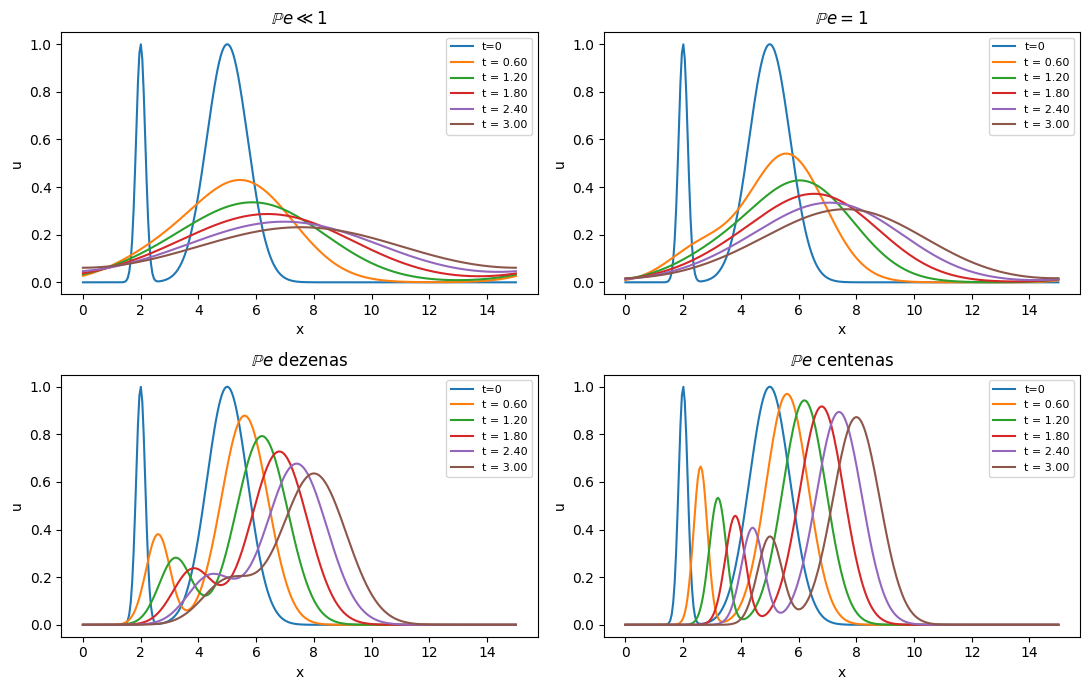

In [9]:
#Faz a lista com as constantes de Péclet
lista_plot = [0.5, 1, 10, 100]
#Monta os títulos
titulos = [r'$\mathbb{P}e \ll 1$', r'$\mathbb{P}e = 1$',
           r'$\mathbb{P}e$ dezenas', r'$\mathbb{P}e$ centenas']

tempos_fixos = np.linspace(0, 3, 6)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

#Faz a montagem dos gráficos a partir dos dados do item anterior
for ax, Pe, titulo in zip(axes, lista_plot, titulos):
    dados = resultados_2[Pe]
    U = dados['U']
    t = dados['t']

    #Interpola para usar os mesmos tempos fixos
    U_interp = np.array([np.interp(tempos_fixos, t, U[:, j]) for j in range(U.shape[1])]).T

    #Monta os gráficos
    for k, t_alvo in enumerate(tempos_fixos):
        label = 't=0' if k == 0 else f't = {t_alvo:.2f}'
        ax.plot(x, U_interp[k, :], label=label)

    ax.set_xlabel('x')
    ax.set_ylabel('u')
    ax.set_title(titulo)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

##Tarefa 3



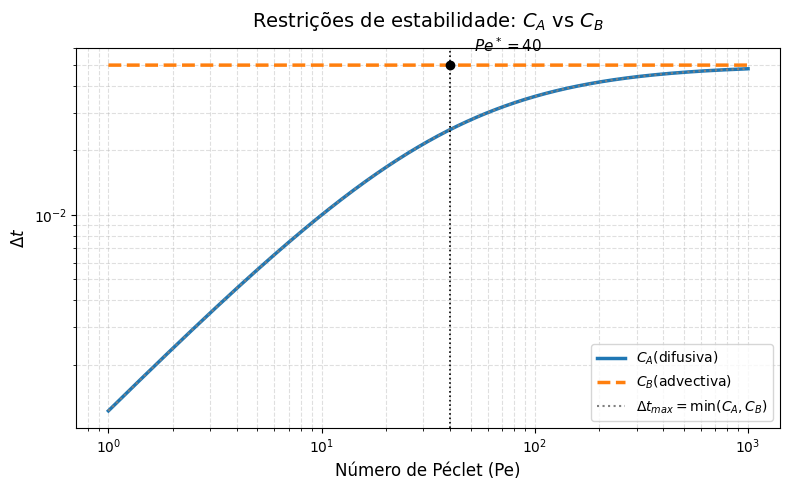

In [10]:
#Monta a lista de Pe e define delta_x
delta_x = 0.05
lista_Pe = np.linspace(1, 1000, 10000)

#Calculamos as duas condições
CA = (delta_x**2) / ((2/lista_Pe) + delta_x)   #restrição difusiva (parabólica)
CB = np.full_like(lista_Pe, delta_x)            #restrição advectiva
restricoes = np.minimum(CA, CB)                 #Delta_t usada no código

#Ponto de transição teórico: Pe* = 2/delta_x
Pe_estrela = 2/delta_x

plt.figure(figsize=(8,5))

#Plotamos as condições
plt.plot(lista_Pe, CA, linewidth=2.5, label=r'$C_A$(difusiva)')
plt.plot(lista_Pe, CB, linewidth=2.5, linestyle='--', label=r'$C_B$(advectiva)')

plt.plot(lista_Pe, restricoes, linewidth=1.5, linestyle=':', color='gray',
         label=r'$\Delta t_{max} = \min(C_A, C_B)$')


#Deixa os gráficos mais bonitos
plt.axvline(Pe_estrela, color='black', linestyle=':', linewidth=1.2)
plt.scatter([Pe_estrela], [delta_x], color='black', zorder=5)
plt.annotate(fr'$Pe^* = {Pe_estrela:.0f}$',
             xy=(Pe_estrela, delta_x), xytext=(Pe_estrela*1.3, delta_x*1.15),
             fontsize=11)

#Muda a escala para log log
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Número de Péclet (Pe)', fontsize=12)
plt.ylabel(r'$\Delta t$', fontsize=12)
plt.title(r'Restrições de estabilidade: $C_A$ vs $C_B$',
          fontsize=14, pad=15)

plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()

plt.show()